<a href="https://colab.research.google.com/github/leobri93/postgraduate-software-engineer-car-classifier/blob/main/Car_Evaluation_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Car Evaluation model training


## Importando dados

In [ ]:
pip install ucimlrepo

In [ ]:
# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
car_evaluation = fetch_ucirepo(id=19)

# data (as pandas dataframes)
X = car_evaluation.data.features
y = car_evaluation.data.targets

# metadata
print(car_evaluation.metadata)

# variable information
print(car_evaluation.variables)


{'uci_id': 19, 'name': 'Car Evaluation', 'repository_url': 'https://archive.ics.uci.edu/dataset/19/car+evaluation', 'data_url': 'https://archive.ics.uci.edu/static/public/19/data.csv', 'abstract': 'Derived from simple hierarchical decision model, this database may be useful for testing constructive induction and structure discovery methods.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1728, 'num_features': 6, 'feature_types': ['Categorical'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1988, 'last_updated': 'Thu Aug 10 2023', 'dataset_doi': '10.24432/C5JP48', 'creators': ['Marko Bohanec'], 'intro_paper': {'ID': 249, 'type': 'NATIVE', 'title': 'Knowledge acquisition and explanation for multi-attribute decision making', 'authors': 'M. Bohanec, V. Rajkovič', 'venue': '8th Intl Workshop on Expert Systems and their Applications, 

## Organizado dados e arrays

In [ ]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

# Define a ordem das categorias para o OrdinalEncoder
# Isso garante um mapeamento consistente para as categorias em String
category_orders = {
    'buying': ['low', 'med', 'high', 'vhigh'],
    'maint': ['low', 'med', 'high', 'vhigh'],
    'doors': ['2', '3', '4', '5more'],
    'persons': ['2', '4', 'more'],
    'lug_boot': ['small', 'med', 'big'],
    'safety': ['low', 'med', 'high']
}

# Inicializa o OrdinalEncoder para as features X
# Garante que as colunas são processadas na ordem correta no modo que aparecem no X_train
feature_cols = X_train.columns.tolist()
ordinal_encoder = OrdinalEncoder(categories=[category_orders[col] for col in feature_cols])

X_train_encoded = ordinal_encoder.fit_transform(X_train)

# Inicializa o LabelEncoder para o target Y
label_encoder = LabelEncoder()

# Aplica o LabelEncoder para o y_train
y_train_encoded = label_encoder.fit_transform(y_train.values.ravel())



## Treinando modelos e fazendo otimizações

KNN: 0.949343 (0.013368)
CART: 0.974669 (0.017826)
NB: 0.696054 (0.032884)
SVM: 0.960937 (0.017151)


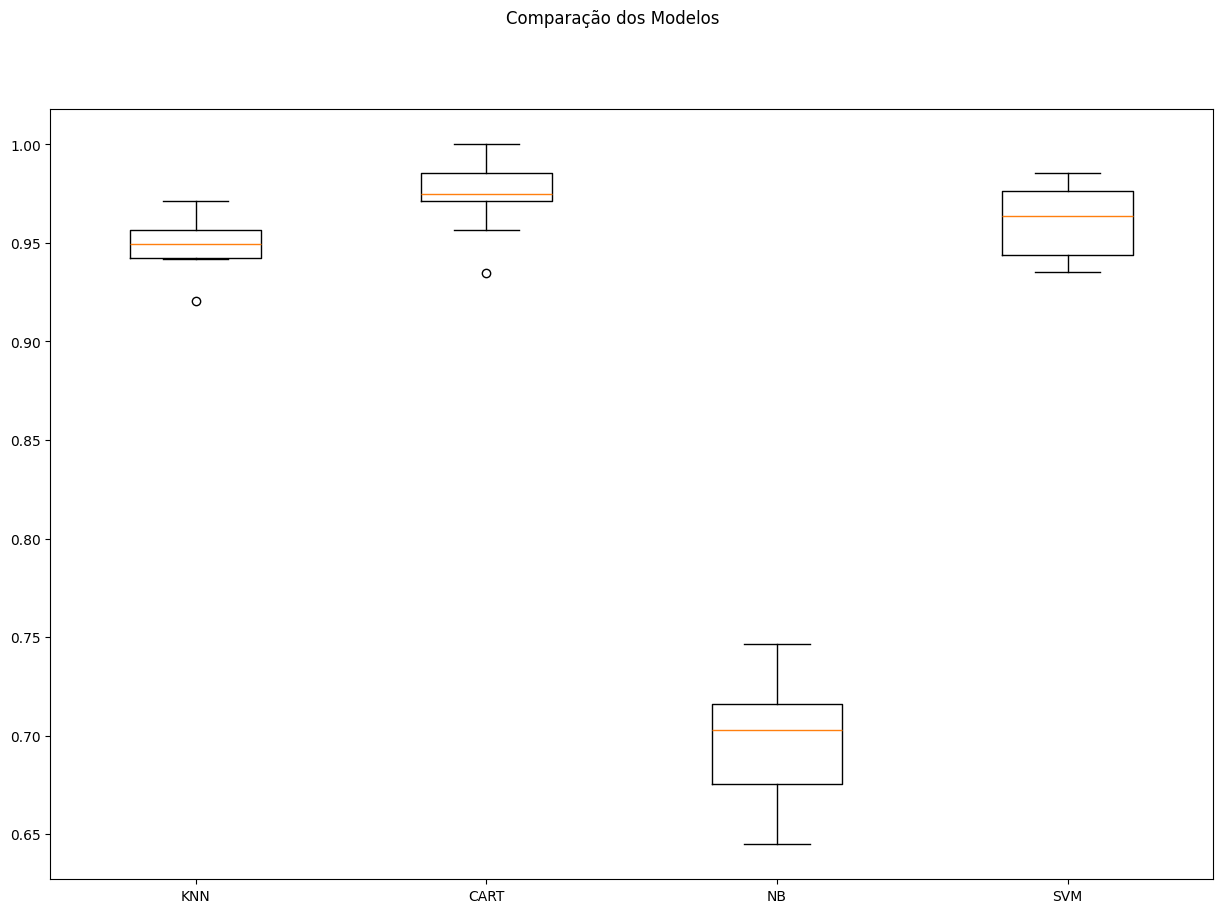

In [ ]:
np.random.seed(7) # definindo uma semente global

# Lista que armazenará os modelos
models = []

# Criando os modelos e adicionando-os na lista de modelos
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))

# Listas para armazenar os resultados
results = []
names = []

# Avaliação dos modelos
for name, model in models:
    # Use the encoded data for cross-validation
    cross_val_results = cross_val_score(model, X_train_encoded, y_train_encoded, cv=kfold, scoring=scoring)
    results.append(cross_val_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cross_val_results.mean(), cross_val_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(15,10))
fig.suptitle('Comparação dos Modelos')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

KNN-orig: 0.949 (0.013)
CART-orig: 0.975 (0.018)
NB-orig: 0.696 (0.033)
SVM-orig: 0.961 (0.017)
KNN-padr: 0.959 (0.018)
CART-padr: 0.972 (0.016)
NB-padr: 0.694 (0.033)
SVM-padr: 0.966 (0.014)
KNN-norm: 0.929 (0.019)
CART-norm: 0.974 (0.017)
NB-norm: 0.694 (0.033)
SVM-norm: 0.965 (0.016)


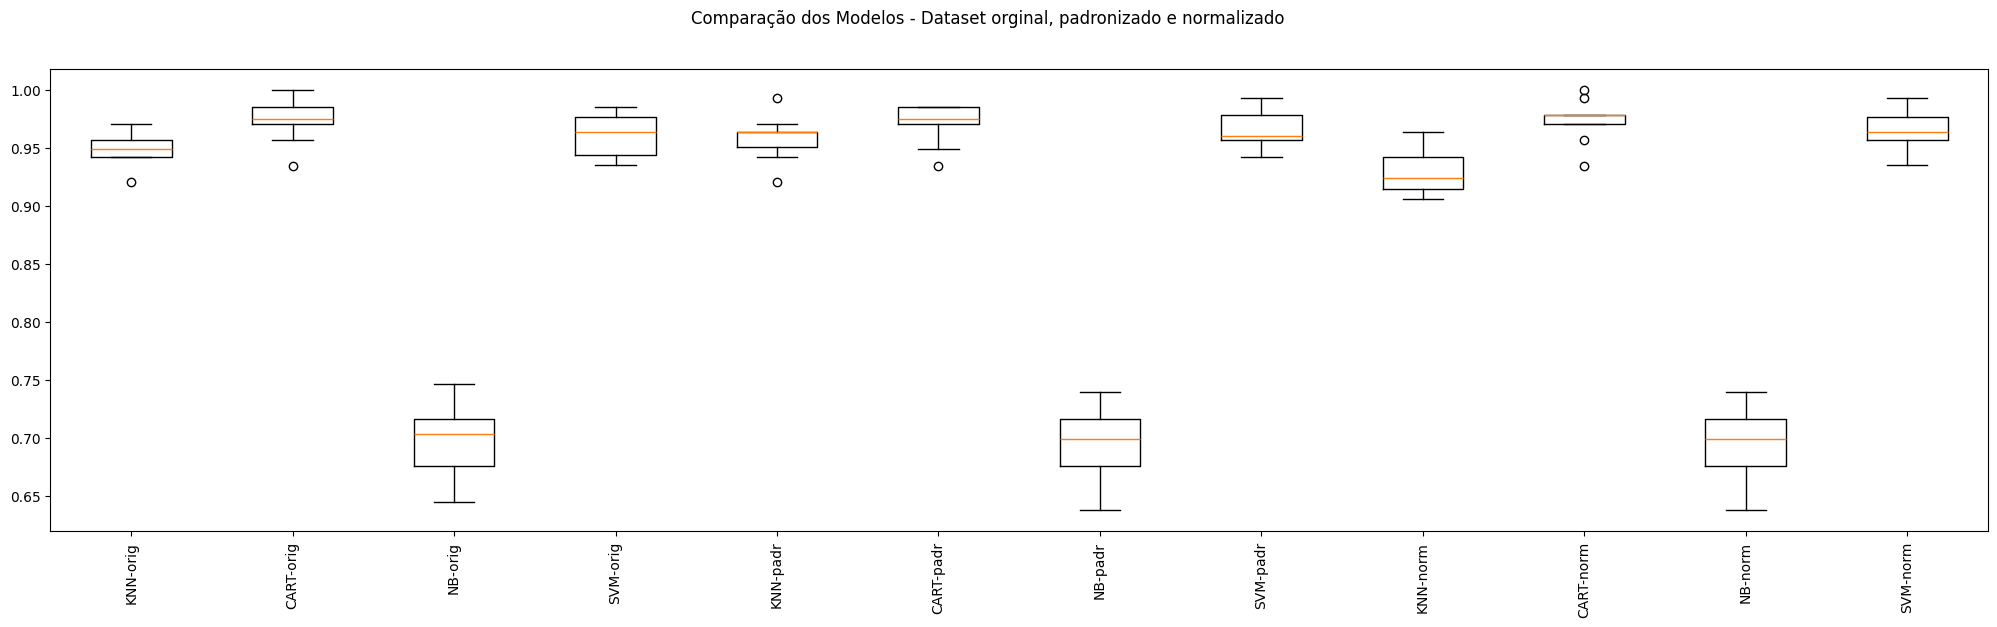

In [ ]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []


# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
svm = ('SVM', SVC())

# Transformações que serão utilizadas
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())


# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('SVM-orig', Pipeline([svm])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('SVM-padr', Pipeline([standard_scaler, svm])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('SVM-norm', Pipeline([min_max_scaler, svm])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train_encoded, y_train_encoded, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.3f (%.3f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

In [ ]:
# Definindo os parametros para o Grid Search
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurando o Grid Search com o modelo CART
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=seed), param_grid, cv=kfold, scoring=scoring)
grid_search.fit(X_train_encoded, y_train_encoded)

# Melhores parametros e score
print(f"Melhores parametros: {grid_search.best_params_}")
print(f"Melhor acuracia na validação cruzada: {grid_search.best_score_:.4f}")

# Avaliando o melhor modelo no conjunto de teste
best_cart = grid_search.best_estimator_
test_predictions = best_cart.predict(X_test_encoded)
print(f"Acuracia final (Best CART) no conjunto de teste: {accuracy_score(y_test_encoded, test_predictions):.4f}")

Melhores parametros: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Melhor acuracia na validação cruzada: 0.9725
Acuracia final (Best CART) no conjunto de teste: 0.9827


## Finalizando modelo

In [ ]:
# Finalizando o modelo escolhido (CART) com os melhores hiperparâmetros encontrados
# e avaliando no conjunto de teste (Holdout)

final_model = DecisionTreeClassifier(criterion='gini',
                                     max_depth=10,
                                     min_samples_leaf=1,
                                     min_samples_split=2,
                                     random_state=seed)

final_model.fit(X_train_encoded, y_train_encoded)

# Preparar o conjunto de teste
X_test_encoded = ordinal_encoder.transform(X_test)
y_test_encoded = label_encoder.transform(y_test.values.ravel())

# Predições
predictions = final_model.predict(X_test_encoded)
print(f"Acurácia final (Tuned CART) no conjunto de teste: {accuracy_score(y_test_encoded, predictions):.4f}")

Acurácia final (Tuned CART) no conjunto de teste: 0.9827


## Conclusão final

### Comparação de Resultados

Após os testes com diferentes algoritmos e técnicas de pré-processamento, os resultados de acurácia média na validação cruzada foram:

1.  **CART (Original/Tuned):** ~0.975 (Vencedor)
2.  **SVM (Padronizado):** ~0.966
3.  **KNN (Padronizado):** ~0.959
4.  **Gaussian NB:** ~0.696

### Por que escolhemos o CART com Tuning?

*   **Performance Superior:** O modelo **CART** obteve a maior acurácia tanto na validação cruzada quanto no conjunto de teste final (**98.27%**).
*   **Ajuste de Hiperparametros (Tuning):** A aplicação dos parametros `max_depth=10` e `criterion='gini'` permitiu criar um modelo que não apenas é preciso, mas também generalista. Ao limitar a profundidade, evitamos o *overfitting* (quando o modelo decora o treino mas falha em dados novos).
*   **Interpretabilidade:** O dataset *Car Evaluation* é baseado em regras lógicas de decisão. árvores de decisão são modelos "caixa-branca", permitindo visualizar claramente como o modelo chegou a uma conclusão sobre a aceitabilidade de um carro (ex: se a segurança é baixa, o carro é inaceitável).
*   **Eficiência:** Diferente do SVM ou KNN, o CART não exigiu escalonamento de dados (StandardScaler/MinMaxScaler) para atingir alta performance, tornando o pipeline de produção mais simples.

**Conclusão:** O modelo CART com tuning é a solução ideal para este problema, equilibrando precisão máxima e alta explicabilidade.

## Exportando modelo

In [ ]:
import joblib

# 1. Treinar o modelo final (escolhido como vencedor no seu notebook)
final_model = DecisionTreeClassifier(max_depth=10, criterion='gini')
final_model.fit(X_train_encoded, y_train_encoded)

# 2. Salvar o modelo e os encoders
joblib.dump(final_model, 'modelo_car_evaluation.joblib')
joblib.dump(ordinal_encoder, 'ordinal_encoder.joblib')
joblib.dump(label_encoder, 'label_encoder.joblib')

['label_encoder.joblib']